# Transfer learning: reutilizar un modelo preentrenado

> Cómo aprovechar una red entrenada con millones de imágenes (ImageNet) para resolver un problema con muy pocos datos: extracción de características, *embeddings* con un clasificador clásico y *fine-tuning*. Qué arquitecturas se usan de base (ResNet, EfficientNet…), cómo se adapta la cabeza del modelo y los errores que lo estropean (otra normalización, una tasa de aprendizaje demasiado alta).
>
> **Requisitos previos:** [Redes convolucionales](03-redes-convolucionales.ipynb) · [Entrenamiento y regularización](02-entrenamiento-y-regularizacion.ipynb) · **Relacionado:** [Autoencoders](05-autoencoders.ipynb) · [Modelos de lenguaje preentrenados](../06-nlp/10-modelos-de-lenguaje-preentrenados.ipynb)

## 1. Idea clave

Entrenar una red convolucional profunda desde cero exige cientos de miles de imágenes etiquetadas y mucho cómputo. El **transfer learning** (aprendizaje por transferencia) parte de una red ya entrenada con un conjunto enorme (típicamente **ImageNet**, 1,28 millones de imágenes de 1 000 clases) y la **reutiliza** para otra tarea: las primeras capas ya saben ver bordes, texturas y formas, y eso sirve para casi cualquier imagen. Se sustituye la última capa (la que decide la clase) por una nueva y se entrena solo esa parte (**extracción de características**) o toda la red con una tasa de aprendizaje pequeña (***fine-tuning***).

Es la opción por defecto cuando se tienen **pocas imágenes** (cientos o unos pocos miles): aquí, con 10 imágenes por clase, partir de cero apenas supera el 20 % de aciertos y *fine-tuning* ronda el 92 %. Es la misma idea que hay detrás de los modelos de lenguaje preentrenados ([NLP](../06-nlp/10-modelos-de-lenguaje-preentrenados.ipynb)).

## 2. Conceptos importantes

### 2.1. Por qué funciona

Las capas de una CNN forman una jerarquía ([redes convolucionales](03-redes-convolucionales.ipynb)): las primeras detectan bordes y colores (**generales**, útiles en casi cualquier imagen) y las últimas, combinaciones específicas de la tarea original (**específicas**). Yosinski y otros mostraron que las capas iniciales son transferibles entre tareas y que la transferibilidad baja a medida que se profundiza y se aleja la tarea. Reutilizar las generales ahorra la mayor parte del aprendizaje.

### 2.2. Estrategias y cuándo usar cada una

| Estrategia | Qué se entrena | Cuándo |
|---|---|---|
| **Extracción de características** (*feature extraction*) | Solo la capa de salida nueva; el resto, congelado | Muy pocos datos y tarea parecida a ImageNet; barata y rápida |
| ***Embeddings* + clasificador clásico** | Un modelo clásico (regresión logística, SVM…) sobre las características extraídas | Igual que la anterior, y además permite usar todo el ecosistema clásico; muy barata |
| ***Fine-tuning* completo** | Toda la red, con tasa pequeña (cabeza mayor que el resto) | Datos moderados, o tarea algo distinta; suele dar lo mejor |
| ***Fine-tuning* parcial** | Solo los últimos bloques | Pocos datos pero con diferencias respecto a ImageNet; menos riesgo de sobreajuste |
| **Entrenar desde cero** | Todo | Muchos datos (cientos de miles) y dominio muy distinto (imagen médica, satélite…) |

### 2.3. Mecánica del *fine-tuning*

1. **Cargar** el modelo con sus pesos preentrenados.
2. **Sustituir la cabeza**: la capa final (`fc` en ResNet) se reemplaza por una `Linear(n_características, n_clases_nuevas)` con pesos aleatorios.
3. **Congelar** (`requires_grad = False`) lo que no se va a entrenar.
4. **Tasas de aprendizaje diferenciadas**: la cabeza nueva (parte de pesos aleatorios) admite una tasa mayor ($10^{-3}$) que el cuerpo preentrenado ($10^{-4}$ o menos): el cuerpo ya es bueno y una tasa alta lo destruiría (3.4).
5. **Normalización por lotes**: con el cuerpo congelado hay que decidir si sus estadísticas siguen siendo las de ImageNet (modo `eval`, estrictamente congelado) o se adaptan al nuevo conjunto (modo `train`); lo comparamos en 3.3.
6. Aumento de datos y parada temprana, como siempre ([regularización](02-entrenamiento-y-regularizacion.ipynb)).

### 2.4. Preprocesar igual que en el preentrenamiento

El modelo aprendió con unas entradas concretas: imágenes de $224\times224$, píxeles en $[0,1]$ y estandarizados con la media $(0{,}485,\,0{,}456,\,0{,}406)$ y la desviación $(0{,}229,\,0{,}224,\,0{,}225)$ de ImageNet. Con otra escala o normalización las activaciones no son las que espera y el rendimiento cae (3.4). Las `weights.transforms()` de `torchvision` aplican la receta correcta.

### 2.5. Arquitecturas de base

- **VGG** (2014): bloques de convoluciones $3\times3$ apiladas; sencilla pero con muchísimos parámetros en sus capas densas.
- **ResNet** (2015): bloques **residuales** con una conexión de atajo, $\mathbf{y}=F(\mathbf{x})+\mathbf{x}$. El gradiente puede viajar por el atajo (la derivada de $\mathbf{x}$ es 1), lo que atenúa el problema del [gradiente que desaparece](01-redes-neuronales-densas.ipynb) y permite entrenar redes de decenas o cientos de capas.
- **MobileNet** (2017–2019): convoluciones **separables en profundidad** (una convolución por canal y otra $1\times1$ para mezclar) que reducen mucho el cálculo; pensadas para móviles.
- **EfficientNet** (2019): escala conjuntamente profundidad, anchura y resolución con un coeficiente compuesto; muy buena relación exactitud/coste.
- ***Vision Transformer*, ViT** (2020): no usa convoluciones; trocea la imagen en parcelas y aplica atención ([transformers](07-atencion-y-transformers.ipynb)).

En 3.1 se comparan con los datos de `torchvision`.

## 3. Código

Usamos **Flowers102**: 102 categorías de flores de Reino Unido. Se usan las particiones oficiales (con un entrenamiento de **solo 1 020 imágenes**, 10 por clase, y 1 020 de validación y 6 149 de test), lo que reproduce el escenario típico de pocos datos. El modelo de base es una **ResNet18** (11,7 millones de parámetros) con pesos de ImageNet. Las imágenes de entrenamiento se recortan al azar a $224\times224$ y se voltean; las de validación y test se redimensionan a 256 y se recortan al centro; todas se normalizan con la media y desviación de ImageNet.

In [1]:
import contextlib
import io
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.deterministic = True                 # resultados reproducibles en GPU (algo más lento)
torch.backends.cudnn.benchmark = False

### 3.1. Arquitecturas disponibles

`torchvision` publica con cada modelo preentrenado su número de parámetros y su exactitud en ImageNet. Las leemos de los metadatos de los pesos (no se descargan los pesos).

In [2]:
anios = {"alexnet": 2012, "vgg16": 2014, "resnet18": 2015, "resnet50": 2015, "mobilenet_v3_large": 2019, "efficientnet_b0": 2019, "vit_b_16": 2020}
filas = {}
for nombre, anio in anios.items():
    meta = models.get_model_weights(nombre).DEFAULT.meta
    filas[nombre] = {"año": anio, "parámetros (millones)": meta["num_params"] / 1e6,
                     "exactitud top-1 en ImageNet (%)": meta["_metrics"]["ImageNet-1K"]["acc@1"], "GFLOPs": meta["_ops"]}
pd.DataFrame(filas).T.round(1).astype({"año": int})

,año,parámetros (millones),exactitud top-1 en ImageNet (%),GFLOPs
alexnet,2012,61.1,56.5,0.7
vgg16,2014,138.4,71.6,15.5
resnet18,2015,11.7,69.8,1.8
resnet50,2015,25.6,80.9,4.1
mobilenet_v3_large,2019,5.5,75.3,0.2
efficientnet_b0,2019,5.3,77.7,0.4
vit_b_16,2020,86.6,81.1,17.6


Entre AlexNet (2012) y EfficientNet-B0 (2019) los parámetros bajan de 61 a 5 millones mientras la exactitud pasa del 57 % al 78 %: las arquitecturas mejoran con ideas, no solo con tamaño. VGG16 (138 millones) es la más pesada y rinde bastante menos que ResNet50 (25,6 millones): 71,6 % frente a 80,9 %. La **ResNet18** (11,7 millones y 70 % en ImageNet) es una base ligera y rápida para estos experimentos.

### 3.2. Datos

entrenamiento 1020, validación 1020, test 6149 (102 clases)


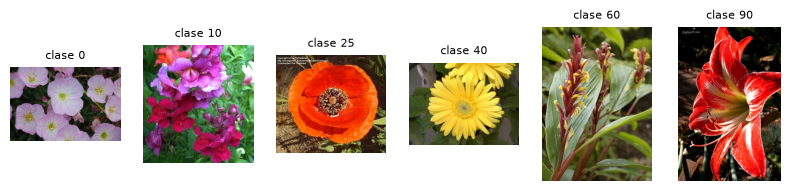

In [3]:
normalizar = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])           # media y desviación de ImageNet
tf_entrenamiento = transforms.Compose([transforms.RandomResizedCrop(224, scale=(0.6, 1.0)), transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalizar])
tf_evaluacion = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(), normalizar])

with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    ds_train = datasets.Flowers102("data", split="train", transform=tf_entrenamiento, download=True)
    ds_val = datasets.Flowers102("data", split="val", transform=tf_evaluacion, download=True)
    ds_test = datasets.Flowers102("data", split="test", transform=tf_evaluacion, download=True)
print(f"entrenamiento {len(ds_train)}, validación {len(ds_val)}, test {len(ds_test)} (102 clases)")

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
visibles = datasets.Flowers102("data", split="train")                                       # sin transformaciones
for ax, i in zip(axes, [0, 100, 250, 400, 600, 900]):
    ax.imshow(visibles[i][0]); ax.set_title(f"clase {visibles[i][1]}", fontsize=8); ax.axis("off")
plt.show()

### 3.3. Cinco formas de resolver el mismo problema

Una función entrena un modelo con AdamW durante unas épocas y registra la exactitud de validación. Comparamos:

1. **Desde cero**: la misma ResNet18 con pesos aleatorios (15 épocas, tasa $10^{-3}$).
2. **Extracción de características**: pesos de ImageNet, cuerpo congelado en modo `eval`, solo se entrena la capa nueva (10 épocas).
3. **Extracción de características con BN adaptable**: igual, pero las estadísticas de la normalización por lotes siguen actualizándose con las flores.
4. ***Embeddings* + regresión logística**: se extraen los 512 valores que da el cuerpo para cada imagen (sin aumento de datos) y se ajusta una regresión logística de scikit-learn.
5. ***Fine-tuning* completo**: toda la red, tasa $10^{-4}$ para el cuerpo y $10^{-3}$ para la cabeza (10 épocas).

In [4]:
def crear_resnet(preentrenada=True, congelar=False):
    with contextlib.redirect_stderr(io.StringIO()):       # silencia el aviso de descarga de los pesos
        modelo = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if preentrenada else None)
    if congelar:
        for p in modelo.parameters():
            p.requires_grad = False
    modelo.fc = nn.Linear(512, 102)                       # cabeza nueva: 102 clases (siempre entrenable)
    return modelo

def cargadores(ds_entrenamiento=None):
    generador = torch.Generator().manual_seed(0)
    train = DataLoader(ds_entrenamiento or ds_train, batch_size=32, shuffle=True, num_workers=8, generator=generador, persistent_workers=True)
    return train, DataLoader(ds_val, batch_size=128, num_workers=8, persistent_workers=True)

def evaluar(modelo, cargador):
    modelo.eval()
    perdida, aciertos = 0.0, 0
    with torch.no_grad():
        for x, y in cargador:
            logits = modelo(x.to(device))
            perdida += F.cross_entropy(logits, y.to(device), reduction="sum").item()
            aciertos += (logits.argmax(1).cpu() == y).sum().item()
    return perdida / len(cargador.dataset), aciertos / len(cargador.dataset)

def entrenar(modelo, grupos, epocas, cargador_train, cargador_val, bn_en_eval=False):
    modelo.to(device)
    opt = torch.optim.AdamW(grupos, weight_decay=1e-4)
    inicio, historial = time.time(), []
    for _ in range(epocas):
        modelo.train()
        if bn_en_eval:                                    # cuerpo estrictamente congelado: BN con las estadísticas de ImageNet
            for capa in modelo.modules():
                if isinstance(capa, nn.BatchNorm2d):
                    capa.eval()
        for x, y in cargador_train:
            opt.zero_grad()
            F.cross_entropy(modelo(x.to(device)), y.to(device)).backward()
            opt.step()
        historial.append(evaluar(modelo, cargador_val))
    return {"parámetros entrenables": sum(p.numel() for p in modelo.parameters() if p.requires_grad),
            "exactitud validación (final)": historial[-1][1], "mejor exactitud validación": max(h[1] for h in historial),
            "tiempo (s)": time.time() - inicio}

def grupos_ajuste_fino(modelo, lr_cuerpo, lr_cabeza):
    cuerpo = [p for n, p in modelo.named_parameters() if not n.startswith("fc")]
    return [{"params": cuerpo, "lr": lr_cuerpo}, {"params": modelo.fc.parameters(), "lr": lr_cabeza}]

dl_train, dl_val = cargadores()
resultados = {}
torch.manual_seed(0); m = crear_resnet(preentrenada=False)
resultados["1. Desde cero (15 épocas)"] = entrenar(m, [{"params": m.parameters(), "lr": 1e-3}], 15, dl_train, dl_val)
torch.manual_seed(0); m = crear_resnet(congelar=True)
resultados["2. Extracción de características (BN congelada)"] = entrenar(m, [{"params": m.fc.parameters(), "lr": 1e-3}], 10, dl_train, dl_val, bn_en_eval=True)
torch.manual_seed(0); m = crear_resnet(congelar=True)
resultados["3. Extracción de características (BN adaptable)"] = entrenar(m, [{"params": m.fc.parameters(), "lr": 1e-3}], 10, dl_train, dl_val)

# 4. Embeddings + regresión logística
torch.manual_seed(0); extractor = crear_resnet(congelar=True); extractor.fc = nn.Identity(); extractor.to(device).eval()
def embeddings(ds):
    cargador, ys, zs = DataLoader(ds, batch_size=128, num_workers=8), [], []
    with torch.no_grad():
        for x, y in cargador:
            zs.append(extractor(x.to(device)).cpu()); ys.append(y)
    return torch.cat(zs).numpy(), torch.cat(ys).numpy()
inicio = time.time()
Z_train, y_train_e = embeddings(datasets.Flowers102("data", split="train", transform=tf_evaluacion))     # sin aumento de datos
Z_val, y_val_e = embeddings(ds_val)
logistica = LogisticRegression(max_iter=2000).fit(Z_train, y_train_e)
resultados["4. Embeddings + regresión logística"] = {"parámetros entrenables": logistica.coef_.size + logistica.intercept_.size,
                                                      "exactitud validación (final)": logistica.score(Z_val, y_val_e),
                                                      "mejor exactitud validación": logistica.score(Z_val, y_val_e), "tiempo (s)": time.time() - inicio}

torch.manual_seed(0); m_ft = crear_resnet()
resultados["5. Fine-tuning completo (cuerpo 1e-4, cabeza 1e-3)"] = entrenar(m_ft, grupos_ajuste_fino(m_ft, 1e-4, 1e-3), 10, dl_train, dl_val)
tabla = pd.DataFrame(resultados).T
tabla["parámetros entrenables"] = tabla["parámetros entrenables"].astype(int)
tabla.round(3)

,parámetros entrenables,exactitud validación (final),mejor exactitud validación,tiempo (s)
1. Desde cero (15 épocas),11228838,0.201,0.233,59.037
2. Extracción de características (BN congelada),52326,0.819,0.819,25.512
3. Extracción de características (BN adaptable),52326,0.847,0.847,25.716
4. Embeddings + regresión logística,52326,0.863,0.863,12.074
"5. Fine-tuning completo (cuerpo 1e-4, cabeza 1e-3)",11228838,0.925,0.925,39.050


(Exactitud en validación con 102 clases; el azar daría 0,01.)

- **Desde cero** (11,2 millones de parámetros entrenables) llega a ≈ 0,20 tras 15 épocas: con 10 imágenes por clase la red no consigue aprender a ver desde cero.
- **Extracción de características**, entrenando **solo 52 326 parámetros** (la capa nueva: $512\cdot102+102$), sube a ≈ 0,82 con la BN congelada y a ≈ 0,85 dejando que la BN se adapte a las flores (las estadísticas de ImageNet no son exactamente las de este conjunto). Tarda unos 25 s.
- **Embeddings + regresión logística** consigue ≈ 0,86 en ≈ 12 s: sin entrenar ninguna red, solo un modelo lineal sobre las 512 características que da el cuerpo. Una línea base muy competitiva y barata.
- **Fine-tuning** completo llega a ≈ 0,92: ajustar el cuerpo a las flores aporta entre 8 y 11 puntos más que congelarlo, a cambio de entrenar los 11,2 millones de parámetros.

### 3.4. Lo que se rompe: otra normalización y una tasa demasiado alta

Repetimos dos experimentos con un error deliberado: (a) extracción de características **sin** la normalización de ImageNet (los píxeles solo en $[0,1]$); (b) *fine-tuning* con una tasa de aprendizaje alta (1e-2 para todo, 5 épocas).

In [5]:
# (a) Sin normalizar con la media y desviación de ImageNet
tf_sin_norm_train = transforms.Compose([transforms.RandomResizedCrop(224, scale=(0.6, 1.0)), transforms.RandomHorizontalFlip(), transforms.ToTensor()])
tf_sin_norm_eval = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor()])
with contextlib.redirect_stderr(io.StringIO()):
    ds_train_sn = datasets.Flowers102("data", split="train", transform=tf_sin_norm_train, download=True)
    ds_val_sn = datasets.Flowers102("data", split="val", transform=tf_sin_norm_eval, download=True)
generador = torch.Generator().manual_seed(0)
dl_train_sn = DataLoader(ds_train_sn, batch_size=32, shuffle=True, num_workers=8, generator=generador, persistent_workers=True)
dl_val_sn = DataLoader(ds_val_sn, batch_size=128, num_workers=8, persistent_workers=True)
torch.manual_seed(0); m = crear_resnet(congelar=True)
sin_norm = entrenar(m, [{"params": m.fc.parameters(), "lr": 1e-3}], 10, dl_train_sn, dl_val_sn, bn_en_eval=True)

# (b) Fine-tuning con una tasa demasiado alta
torch.manual_seed(0); m = crear_resnet()
tasa_alta = entrenar(m, grupos_ajuste_fino(m, 1e-2, 1e-2), 5, dl_train, dl_val)

errores = pd.DataFrame({"(a) Extracción sin la normalización de ImageNet": sin_norm, "(b) Fine-tuning con tasa 1e-2 (5 épocas)": tasa_alta}).T
errores[["exactitud validación (final)", "mejor exactitud validación"]].round(3)

,exactitud validación (final),mejor exactitud validación
(a) Extracción sin la normalización de ImageNet,0.734,0.753
(b) Fine-tuning con tasa 1e-2 (5 épocas),0.047,0.047


Sin normalizar como ImageNet, la extracción de características baja de ≈ 0,82 a ≈ 0,73: las activaciones del cuerpo no son las que sus capas esperan. Con una tasa de $10^{-2}$ el *fine-tuning* **destruye** lo aprendido: la exactitud se queda en ≈ 0,05 (el azar sería 0,01), mucho peor que si se hubiera dejado el cuerpo congelado (0,82) o se hubiera usado $10^{-4}$ (0,92). Los pasos grandes sobrescriben los pesos preentrenados antes de que la cabeza nueva sea útil.

### 3.5. Evaluación final en test

Evaluamos **una sola vez** el mejor modelo (el *fine-tuning* de 3.3) en las 6 149 imágenes de test, que no se han usado para decidir nada.

In [6]:
dl_test = DataLoader(ds_test, batch_size=128, num_workers=8)
test_perdida, test_exactitud = evaluar(m_ft, dl_test)
print(f"Test (una sola vez): exactitud {test_exactitud:.3f}, pérdida {test_perdida:.3f}")

Test (una sola vez): exactitud 0.897, pérdida 0.467


La exactitud en test (0,897) es algo menor que la de validación (0,925), como era de esperar: la validación se usó para elegir (modelo y tasas), y el test no. Con solo 1 020 imágenes de entrenamiento se reconocen 102 especies de flores con un 90 % de aciertos, algo imposible desde cero.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Elemento | Qué controla | Consejo |
|---|---|---|
| **Pesos** (`weights=`) | Con qué datos se preentrenó | `IMAGENET1K_V1` para empezar; hay pesos más recientes (`DEFAULT`) con mejor exactitud |
| **Cabeza nueva** | Capa de salida para tus clases | Siempre se sustituye; es la única con pesos aleatorios |
| **Congelar** (`requires_grad=False`) | Qué capas se entrenan | Todo el cuerpo con pocos datos; los últimos bloques con datos moderados; todo con muchos |
| **Tasa del cuerpo / de la cabeza** | Qué tanto se modifica lo preentrenado | Cuerpo `1e-5`–`1e-4`, cabeza `1e-3`; 10–100 veces menos en el cuerpo (3.4) |
| **Modo de la BN** | Estadísticas de la normalización | `eval` (congelada) o `train` (adaptable); probar ambas (3.3) |
| **Normalización y tamaño de entrada** | Compatibilidad con el preentrenamiento | Media y desviación de ImageNet, $224\times224$ (3.4); usa `weights.transforms()` |
| **Aumento de datos** | Variabilidad con pocos datos | Recorte y volteo; solo en entrenamiento |

### 4.2. Errores comunes

- **No normalizar como el modelo espera** (3.4): el rendimiento cae sin ningún error visible.
- **Tasa de aprendizaje demasiado alta** en el *fine-tuning* (3.4): destruye los pesos preentrenados. Empieza por una tasa pequeña (cuerpo 10 veces menor que la de la cabeza).
- **Olvidar sustituir la cabeza** o dejarla con el número de clases de ImageNet (1 000): la pérdida no tiene sentido o hay un error de dimensiones.
- **Entrenar más de lo necesario.** Con pocos datos el *fine-tuning* sobreajusta rápido: usa aumento de datos y parada temprana ([regularización](02-entrenamiento-y-regularizacion.ipynb)).
- **Descartar la alternativa sencilla.** Los *embeddings* con un clasificador clásico (3.3) rindieron más que entrenar la cabeza de la red (0,863 frente a 0,82–0,85) en la mitad de tiempo, y son la línea base natural.
- **Contaminación entre el preentrenamiento y el test.** Si imágenes del test estuvieron en ImageNet, la exactitud se infla; conviene saber qué datos vio el modelo base.
- **Mismatch de dominio.** Con imágenes muy distintas de las naturales (radiografías, satélite) las características de ImageNet transfieren peor; hace falta más *fine-tuning* y más datos.
- **Congelar mal.** Congelar los parámetros pero dejar la BN en modo `train` cambia sus estadísticas (a veces mejora, 3.3, y a veces estropea): decídelo de forma explícita.
- **Perder la reproducibilidad.** Fija las semillas y el modo determinista de cuDNN, y guarda qué pesos preentrenados usaste.
- **Licencias.** Los pesos preentrenados tienen licencia propia (algunos no permiten uso comercial); revísala antes de desplegar.

## 5. Comparación con métodos relacionados

Con 1 020 imágenes de entrenamiento y 102 clases (resultados de 3.3):

| Enfoque | Exactitud en validación | Parámetros entrenados | Tiempo | Cuándo usarlo |
|---|---|---|---|---|
| **Desde cero** | ≈ 0,20 | 11,2 M | ≈ 1 min | Muchos datos y dominio muy distinto |
| **Extracción de características** | ≈ 0,82–0,85 | 52 mil | ≈ 25 s | Muy pocos datos; tarea parecida a ImageNet |
| ***Embeddings* + regresión logística** | ≈ 0,86 | 52 mil | ≈ 12 s | Primera línea base; sin entrenar redes |
| ***Fine-tuning* completo** | ≈ 0,92 | 11,2 M | ≈ 40 s | Datos moderados; da la mejor exactitud |

Frente a los métodos de [aprendizaje automático clásico](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb), el *transfer learning* sustituye la ingeniería de características (HOG, SIFT…) por características aprendidas en un conjunto enorme. En texto el equivalente son los modelos de lenguaje preentrenados ([NLP](../06-nlp/10-modelos-de-lenguaje-preentrenados.ipynb)), y en imágenes los modelos fundacionales actuales extienden la idea (clasificar sin entrenar, o con muy pocos ejemplos).

## 6. Referencias

### Fuentes

- Nilsback, M.-E. y Zisserman, A. (2008). «Automated flower classification over a large number of classes». *Indian Conference on Computer Vision, Graphics and Image Processing (ICVGIP)*. Origen de [Flowers102](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/), descargado con [`torchvision.datasets.Flowers102`](https://pytorch.org/vision/stable/generated/torchvision.datasets.Flowers102.html).
- Russakovsky, O. y otros (2015). «ImageNet large scale visual recognition challenge». *International Journal of Computer Vision*, 115(3), 211–252. Conjunto con el que se preentrenan los pesos usados.
- PyTorch: [*Models and pre-trained weights*](https://pytorch.org/vision/stable/models.html), [`resnet18`](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html), [*Transfer learning tutorial*](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html). scikit-learn: [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

### Para saber más

- He, K., Zhang, X., Ren, S. y Sun, J. (2016). [«Deep residual learning for image recognition»](https://doi.org/10.1109/CVPR.2016.90). *IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, 770–778. El artículo de ResNet y de las conexiones residuales.
- Yosinski, J., Clune, J., Bengio, Y. y Lipson, H. (2014). [«How transferable are features in deep neural networks?»](https://arxiv.org/abs/1411.1792). *Advances in Neural Information Processing Systems* 27 (NeurIPS 2014). Estudia qué capas transfieren y cuánto.